# 修改前


★ 自动选择 K_CUT = 3

=== Energy cumulative ratio ===
K =  1  →   0.837
K =  2  →   0.974
K =  3  →   0.990
K =  4  →   0.996
K =  5  →   0.998

▶ evolve_full ...


/tmp/ipykernel_33111/3900454875.py:94: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  return st.reshape(2, 2 ** nx, 2 ** ny)
/tmp/ipykernel_33111/3900454875.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


▶ evolve_trunc ...

=== 结果 ===
模态数 r = 98,  量子比特 q = 7
L2-rel-err   = 5.543e-02
max-abs-err  = 1.171e-05


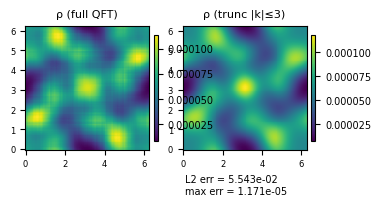

In [16]:
#!/usr/bin/env python3
# original_pod_compare.ipynb  -----------------------------------------------
# 目的：
#   1) 复现原论文中的完整演化
#   2) 实现 “频域截断 + 低维演化” 并自动选 K_CUT (≥99% 能量)
#   3) 打印能量累积表、误差指标，画出对比图
# ---------------------------------------------------------------------------
# 参数：在# 3. 构造初态部分修改
#   1）N = 2**7 # N = 2**7 表示每个维度用7个bit，一共14bit
#   2）dt = 10.0 单步演化时间
#   3）sigma = 3.0 涡核影响范围
# ---------------------------------------------------------------------------
import numpy as np
from numpy import pi, exp, sqrt, real, imag
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
from qiskit.circuit.library import Diagonal

# ---------------------------------------------------------------------------
# 0. 通用工具
# ---------------------------------------------------------------------------
def compute_fluid_quantities(psi1, psi2):
    """给定 ψ1, ψ2  → ρ, ux, uy, vor"""
    N = psi1.shape[0]
    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)

    psi1_k = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j * KX * psi1_k)
    dpsi1_y = np.fft.ifft2(1j * KY * psi1_k)

    psi2_k = np.fft.fft2(psi2)
    dpsi2_x = np.fft.ifft2(1j * KX * psi2_k)
    dpsi2_y = np.fft.ifft2(1j * KY * psi2_k)

    rho = np.abs(psi1) ** 2 + np.abs(psi2) ** 2
    ux = real(real(psi1) * imag(dpsi1_x) - imag(psi1) * real(dpsi1_x)
              + real(psi2) * imag(dpsi2_x) - imag(psi2) * real(dpsi2_x)) / rho
    uy = real(real(psi1) * imag(dpsi1_y) - imag(psi1) * real(dpsi1_y)
              + real(psi2) * imag(dpsi2_y) - imag(psi2) * real(dpsi2_y)) / rho
    vor = real(np.fft.ifft2(1j * KX * np.fft.fft2(uy)
                            - 1j * KY * np.fft.fft2(ux)))
    return rho, ux, uy, vor


# ---------------------------------------------------------------------------
# 1. 原始 QFT-Trotter 演化
# ---------------------------------------------------------------------------
def kinetic_operator(n, dt):
    """构造 1D 动能相位门 (论文公式)"""
    qc = QuantumCircuit(n)
    qc.rz(-2 ** (n - 1) * dt, n - 1)
    for i in range(n):
        qc.rz(2 ** (n - i - 2) * dt, n - i - 1)
    for i in range(1, n):
        qc.cx(n - 1, n - i - 1)
        qc.rz(-2 ** (2 * n - i - 2) * dt, n - i - 1)
        qc.cx(n - 1, n - i - 1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n - i - 1, n - j - 1)
                qc.rz(2 ** (2 * n - i - j - 4) * dt, n - j - 1)
                qc.cx(n - i - 1, n - j - 1)
    return qc


def evolve_full(nx, ny, dt, init_state):
    """完整 QFT-Trotter（原算法）"""
    qn = nx + ny + 1
    circ = QuantumCircuit(qn)
    circ.initialize(init_state)
    circ.barrier()

    from qiskit.circuit.library import QFT
    qft_x, qft_y = QFT(nx), QFT(ny)
    iqft_x, iqft_y = qft_x.inverse(), qft_y.inverse()
    kin_x, kin_y = kinetic_operator(nx, dt), kinetic_operator(ny, dt)

    circ.append(qft_x, range(nx))
    circ.append(qft_y, range(nx, nx + ny))
    circ.append(kin_x, range(nx))
    circ.append(kin_y, range(nx, nx + ny))
    circ.append(iqft_x, range(nx))
    circ.append(iqft_y, range(nx, nx + ny))
    circ.save_state()

    sim = AerSimulator(method='statevector')
    circ = transpile(circ, sim, optimization_level=1)
    st = sim.run(circ).result().data(0)['statevector']
    return st.reshape(2, 2 ** nx, 2 ** ny)


# ---------------------------------------------------------------------------
# 2. 频域截断 + 低维演化
# ---------------------------------------------------------------------------
def auto_select_K(psi1_k, psi2_k, ratio=0.99):
    """自动找最小 K 使能量累计 ≥ ratio"""
    energy = np.abs(psi1_k) ** 2 + np.abs(psi2_k) ** 2
    total_E = energy.sum()
    N = psi1_k.shape[0]
    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)
    k_abs = np.sqrt(KX ** 2 + KY ** 2)
    for K in range(1, N // 2):
        if energy[k_abs <= K].sum() / total_E >= ratio:
            return K
    return N // 2 - 1  # 极端情况


from typing import List, Tuple
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import Diagonal

def make_mask(N: int, K: int, window: str, include_edges: bool) -> List[Tuple[int, int]]:
    """生成频谱索引掩码列表"""
    mask = []

    # ① 周期性边界（Nyquist） |kx|=N/2 或 |ky|=N/2
    if include_edges:
        for ix in (-N // 2, 0, +N // 2):
            for iy in (-N // 2, 0, +N // 2):
                if not (ix == iy == 0):
                    mask.append((ix, iy))

    # ② 按窗口形状补其余
    for ix in range(-K, K + 1):
        for iy in range(-K, K + 1):
            if window == "cross" and not ((abs(ix) <= K) or (abs(iy) <= K)):
                continue
            if window == "square" and not ((abs(ix) <= K) and (abs(iy) <= K)):
                continue
            if window == "diamond" and not ((abs(ix) + abs(iy)) <= K):
                continue
            if (ix, iy) not in mask:          # 去重
                mask.append((ix, iy))
    return mask


def evolve_trunc(
    psi1_0: np.ndarray,
    psi2_0: np.ndarray,
    dt: float,
    K_cut: int,
    window: str = "cross",
    include_edges: bool = False,
):
    """
    频域截断 + 低维对角演化

    Parameters
    ----------
    psi1_0, psi2_0 : ndarray (N×N)
        初态两分量复波函数
    dt : float
        时间步
    K_cut : int
        截断波数半径
    window : {"cross", "square", "diamond"}
        选择掩码形状
    include_edges : bool
        是否优先保留 Nyquist 边界频率

    Returns
    -------
    psi1_t, psi2_t : ndarray
        演化后两分量实空间波函数
    r : int
        截断后总模态数 (两分量之和)
    q : int
        所需量子比特数
    """
    N = psi1_0.shape[0]

    # -------- 1. 生成掩码 (频率索引列表) -----------------
    mask = make_mask(N, K_cut, window, include_edges)

    r = 2 * len(mask)               # 两分量
    q = int(np.ceil(np.log2(r)))
    state_dim = 1 << q

    # -------- 2. 取出截断系数 (未归一) -------------------
    psi1_k = np.fft.fft2(psi1_0)
    psi2_k = np.fft.fft2(psi2_0)

    coeff_raw = []
    for ix, iy in mask:
        coeff_raw.append(psi1_k[(iy + N) % N, (ix + N) % N])
    for ix, iy in mask:
        coeff_raw.append(psi2_k[(iy + N) % N, (ix + N) % N])
    coeff_raw = np.array(coeff_raw, dtype=complex)

    orig_norm = np.linalg.norm(coeff_raw)      # 记录原范数
    coeff = coeff_raw / orig_norm              # 归一化→量子态

    full_state = np.zeros(state_dim, dtype=complex)
    full_state[:r] = coeff

    # -------- 3. 对角相位 (e^{-i(kx²+ky²)dt/2}) ----------
    kx_modes = [ix for ix, iy in mask] * 2
    ky_modes = [iy for ix, iy in mask] * 2
    phase = np.exp(-0.5j * dt * (np.array(kx_modes) ** 2 + np.array(ky_modes) ** 2))

    diag = np.ones(state_dim, dtype=complex)
    diag[:r] = phase

    # -------- 4. 量子电路 -------------------------------
    qc = QuantumCircuit(q)
    qc.initialize(full_state, qc.qubits)
    qc.append(Diagonal(diag), qc.qubits)
    qc.save_state()

    sim = AerSimulator(method="statevector")
    qc = transpile(qc, sim, optimization_level=1)
    psi_t = sim.run(qc).result().data(0)["statevector"]

    # -------- 5. 重构谱矩阵 → IFFT ----------------------
    psi1_k_t = np.zeros_like(psi1_k)
    psi2_k_t = np.zeros_like(psi2_k)
    m = 0
    for ix, iy in mask:
        psi1_k_t[(iy + N) % N, (ix + N) % N] = psi_t[m]; m += 1
    for ix, iy in mask:
        psi2_k_t[(iy + N) % N, (ix + N) % N] = psi_t[m]; m += 1

    psi1_t = np.fft.ifft2(psi1_k_t) * orig_norm   # 乘回原范数
    psi2_t = np.fft.ifft2(psi2_k_t) * orig_norm


    # ★ 让整态再次满足总概率 = 1 ★
    total_norm = np.sqrt((np.abs(psi1_t)**2 + np.abs(psi2_t)**2).sum())
    psi1_t /= total_norm
    psi2_t /= total_norm

    return psi1_t, psi2_t, r, q




# ---------------------------------------------------------------------------
# 3. 构造初态
# ---------------------------------------------------------------------------
N = 2 ** 7           # 可改 2**7 等
dt = 10.0
sigma = 3.0

# ---- 3.1 构造原始两分量波函数 (与你原脚本一致) ----
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
# 原代码 (涡核在中心)
# R = sqrt(X**2 + Y**2)  # 默认以(0,0)为中心

# 调整为 (x0,y0) 处的涡核
x0 = 0  # 涡核中心x坐标
y0 = 0 # 涡核中心y坐标
R = sqrt((X - x0)**2 + (Y - y0)**2)  # 相对涡核中心的距离
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)

# ---------- FFT 频谱，用于能量分析 ----------
psi1_k0 = np.fft.fft2(psi1_0)
psi2_k0 = np.fft.fft2(psi2_0)

# ---------- 自动选 K_CUT (≥99% 谱能量) ----------
K_CUT = auto_select_K(psi1_k0, psi2_k0, ratio=0.99)
#K_CUT = 20
print(f"\n★ 自动选择 K_CUT = {K_CUT}\n")

# ---------- 能量累积表 & 可视 debug ----------
energy = np.abs(psi1_k0) ** 2 + np.abs(psi2_k0) ** 2
total_E = energy.sum()
kx = np.fft.fftfreq(N) * N
ky = np.fft.fftfreq(N) * N
KX, KY = np.meshgrid(kx, ky)
k_abs = np.sqrt(KX ** 2 + KY ** 2)

print("=== Energy cumulative ratio ===")
for K in range(1, K_CUT + 3):
    ratio = energy[k_abs <= K].sum() / total_E
    print(f"K = {K:2d}  →  {ratio:6.3f}")

# ---------------------------------------------------------------------------
# 4. 运行两种演化
# ---------------------------------------------------------------------------
print("\n▶ evolve_full ...")
init_state_full = np.vstack([psi1_0, psi2_0]).reshape(-1)
init_state_full /= np.linalg.norm(init_state_full)
psi_full = evolve_full(int(np.log2(N)), int(np.log2(N)), dt, init_state_full)
rho_full, *_ = compute_fluid_quantities(psi_full[0], psi_full[1])

print("▶ evolve_trunc ...")
psi1_t, psi2_t, r, q = evolve_trunc(psi1_0, psi2_0, dt, K_CUT)
rho_trunc, *_ = compute_fluid_quantities(psi1_t, psi2_t)

# ---------------------------------------------------------------------------
# 5. 误差
# ---------------------------------------------------------------------------
l2_err = np.linalg.norm(rho_trunc - rho_full) / np.linalg.norm(rho_full)
inf_err = np.abs(rho_trunc - rho_full).max()
print(f"\n=== 结果 ===")
print(f"模态数 r = {r},  量子比特 q = {q}")
print(f"L2-rel-err   = {l2_err:.3e}")
print(f"max-abs-err  = {inf_err:.3e}")

# ---------------------------------------------------------------------------
# 6. 密度对比图 (8 cm × 8 cm)
# ---------------------------------------------------------------------------
fig_w = fig_h = 8 / 2.54
fig = plt.figure(figsize=(fig_w, fig_h))

def quick_ax(position):
    ax = fig.add_axes(position)
    ax.set_box_aspect(1)
    ax.tick_params(labelsize=6)
    return ax

ax1 = quick_ax([0.00, 0.52, 0.48, 0.48])
ax2 = quick_ax([0.50, 0.52, 0.48, 0.48])

Xg, Yg = np.meshgrid(np.linspace(0, 2 * pi, N, endpoint=False),
                     np.linspace(0, 2 * pi, N, endpoint=False))

im1 = ax1.pcolormesh(Xg, Yg, rho_full, cmap='viridis', shading='auto')
im2 = ax2.pcolormesh(Xg, Yg, rho_trunc, cmap='viridis', shading='auto')
fig.colorbar(im1, ax=ax1, shrink=0.7, aspect=25, pad=0.03)
fig.colorbar(im2, ax=ax2, shrink=0.7, aspect=25, pad=0.03)
ax1.set_title("ρ (full QFT)", fontsize=8)
ax2.set_title(f"ρ (trunc |k|≤{K_CUT})", fontsize=8)



ax2.text(0.02, -0.20, f"L2 err = {l2_err:.3e}\nmax err = {inf_err:.3e}",
         transform=ax2.transAxes, fontsize=7, va='top')

plt.tight_layout()
plt.show()


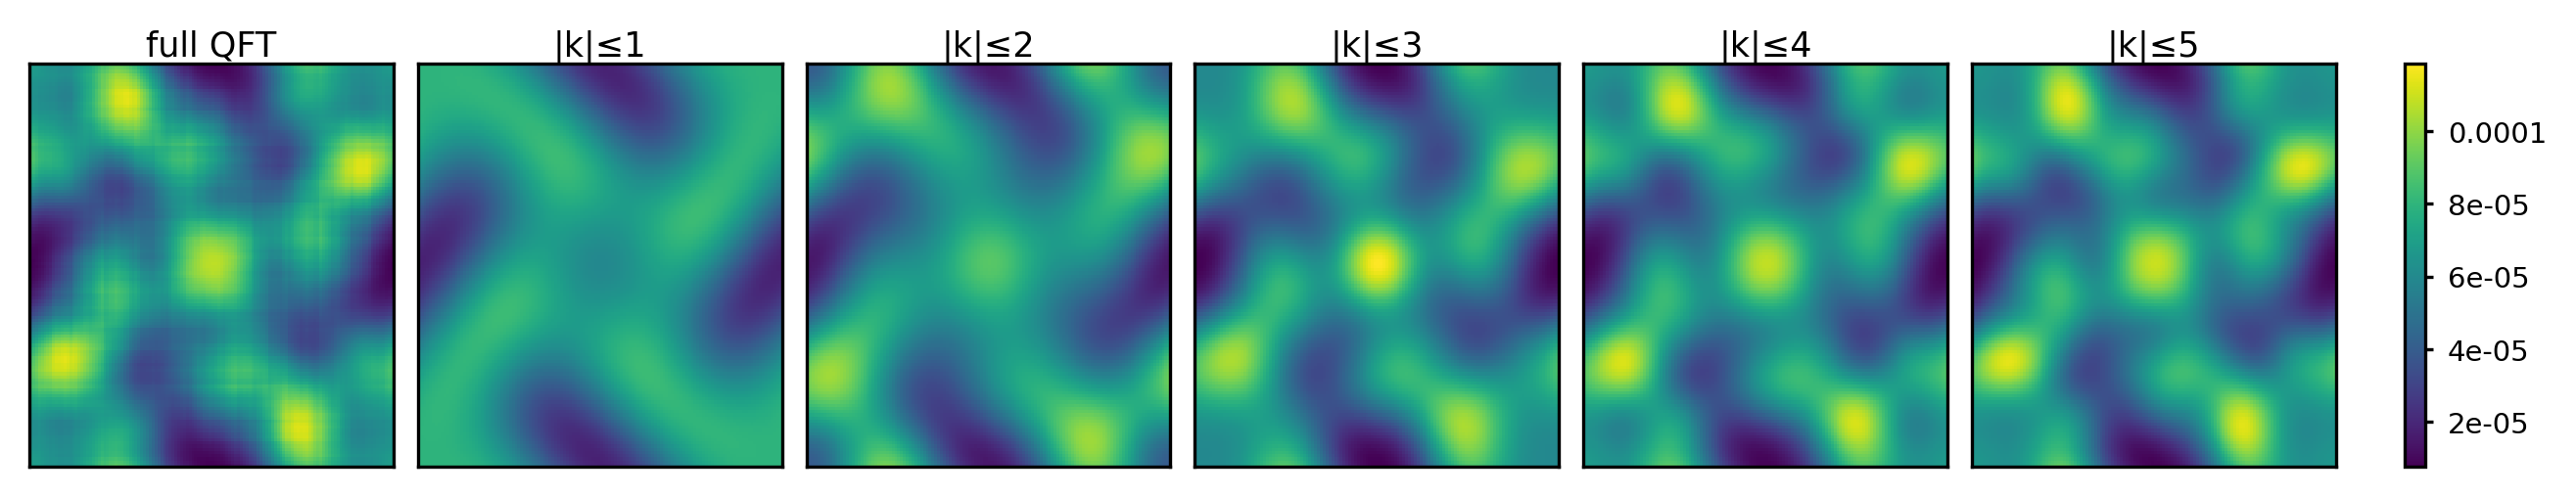

In [17]:
# ---------------------------------------------------------------------------
# 6. ρ-field comparison: full-QFT vs. K = 1…5  (HD 300 dpi, shared colorbar)
# ---------------------------------------------------------------------------
import matplotlib as mpl
mpl.rcParams.update({"font.size": 7})          # 全局统一字号

Ks = range(1, 6)                               # 要展示的截断 K
rho_trunc_list = []                            # 存每个截断 ρ

for K in Ks:
    psi1_t, psi2_t, *_ = evolve_trunc(psi1_0, psi2_0, dt, K)
    rho_t, *_ = compute_fluid_quantities(psi1_t, psi2_t)
    rho_trunc_list.append(rho_t)

# -- 把 full-QFT 结果插到最前面 --------------------------------------------
titles = ["full QFT", *[f"|k|≤{K}" for K in Ks]]
rho_all = [rho_full, *rho_trunc_list]

# -- 统一颜色范围 -----------------------------------------------------------
vmin = min(rho.min() for rho in rho_all)
vmax = max(rho.max() for rho in rho_all)

# -- Figure & axes ----------------------------------------------------------
fig_w = 22 / 2.54   # ≈ 22 cm 宽：6 图够用
fig_h = 4  / 2.54   # ≈  4 cm 高
fig, axs = plt.subplots(1, len(rho_all),
                        figsize=(fig_w, fig_h),
                        dpi=300,                # ★ 高清输出
                        constrained_layout=True)

# 网格坐标一次生成
Xg, Yg = np.meshgrid(np.linspace(0, 2 * pi, N, endpoint=False),
                     np.linspace(0, 2 * pi, N, endpoint=False))

for ax, title, rho in zip(axs, titles, rho_all):
    im = ax.pcolormesh(Xg, Yg, rho, cmap="viridis",
                       shading="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=2)
    ax.set_xticks([]); ax.set_yticks([])

# -- 共享颜色条 -------------------------------------------------------------
cbar = fig.colorbar(im, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.03)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2g'))
cbar.ax.tick_params(length=2)

plt.show()


In [18]:
# ---------------------------------------------------------------------------
# 7. 生成 K = 1…5 的误差指标，并输出 LaTeX 表
# ---------------------------------------------------------------------------
Ks = range(1, 6)                 # 欲评估的截断半径
rows = []

for K in Ks:
    psi1_t, psi2_t, *_ = evolve_trunc(psi1_0, psi2_0, dt, K)
    rho_t, *_             = compute_fluid_quantities(psi1_t, psi2_t)

    l2_err  = np.linalg.norm(rho_t - rho_full) / np.linalg.norm(rho_full)
    inf_err = np.abs(rho_t - rho_full).max()
    rows.append((K, l2_err, inf_err))

# -- 组装 LaTeX -------------------------------------------------------------
header = r"""\begin{tabular}{c S[scientific-notation=true] S[scientific-notation=true]}
\toprule
{$K$} & {$L_2$-rel-err} & {max-abs-err} \\
\midrule
"""
body   = "\n".join([f"{k} & {l2:.2e} & {inf:.2e} \\\\" for k, l2, inf in rows])
footer = r"""\bottomrule
\end{tabular}"""

latex_table = header + body + "\n" + footer
print(latex_table)

# 若想写进文件：
# with open("k_metrics_table.tex", "w") as f:
#     f.write(latex_table)


\begin{tabular}{c S[scientific-notation=true] S[scientific-notation=true]}
\toprule
{$K$} & {$L_2$-rel-err} & {max-abs-err} \\
\midrule
1 & 2.21e-01 & 4.82e-05 \\
2 & 1.24e-01 & 2.94e-05 \\
3 & 5.54e-02 & 1.17e-05 \\
4 & 3.37e-02 & 9.14e-06 \\
5 & 2.18e-02 & 5.89e-06 \\
\bottomrule
\end{tabular}


/tmp/ipykernel_33111/1243991427.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


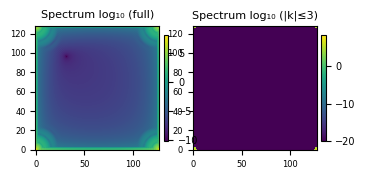

In [19]:
# ---------------------------------------------------------------------------
# 7. 谱能量对比图  (8 cm × 8 cm)
# 不知道怎么解释，待定
# ---------------------------------------------------------------------------
fig_w = fig_h = 8 / 2.54
fig = plt.figure(figsize=(fig_w, fig_h))
def quick_ax(pos):
    ax = fig.add_axes(pos)
    ax.set_box_aspect(1)
    ax.tick_params(labelsize=6)
    return ax

ax_full  = quick_ax([0.00, 0.00, 0.48, 0.48])
ax_trunc = quick_ax([0.50, 0.00, 0.48, 0.48])

# 取对数后显示能量谱
im_full  = ax_full.imshow(np.log10(energy + 1e-20), origin='lower')
im_trunc = ax_trunc.imshow(np.log10(energy * (k_abs <= K_CUT) + 1e-20),
                           origin='lower')

fig.colorbar(im_full,  ax=ax_full,  shrink=0.7, aspect=25, pad=0.03)
fig.colorbar(im_trunc, ax=ax_trunc, shrink=0.7, aspect=25, pad=0.03)

ax_full.set_title("Spectrum log₁₀ (full)",             fontsize=8)
ax_trunc.set_title(f"Spectrum log₁₀ (|k|≤{K_CUT})",    fontsize=8)


plt.tight_layout()
plt.show()


# 修改后版本 把高能量谱点“展平排序法” 似乎没什么变化


★ 自动选择 K_CUT = 3

=== Energy cumulative ratio ===
K =  1  →   0.837
K =  2  →   0.974
K =  3  →   0.990
K =  4  →   0.996
K =  5  →   0.998

▶ evolve_full ...


/tmp/ipykernel_33111/2652075547.py:94: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  return st.reshape(2, 2 ** nx, 2 ** ny)


▶ evolve_trunc ...

=== 结果 ===
模态数 r = 98,  量子比特 q = 7
L2-rel-err   = 5.543e-02
max-abs-err  = 1.171e-05


/tmp/ipykernel_33111/2652075547.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


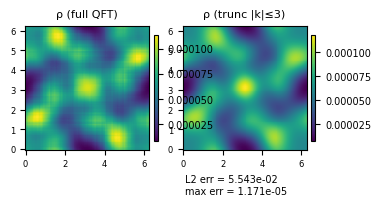

In [22]:
#!/usr/bin/env python3
# original_pod_compare.ipynb  -----------------------------------------------
# 目的：
#   1) 复现原论文中的完整演化
#   2) 实现 “频域截断 + 低维演化” 并自动选 K_CUT (≥99% 能量)
#   3) 打印能量累积表、误差指标，画出对比图
# ---------------------------------------------------------------------------
# 参数：在# 3. 构造初态部分修改
#   1）N = 2**7 # N = 2**7 表示每个维度用7个bit，一共14bit
#   2）dt = 10.0 单步演化时间
#   3）sigma = 3.0 涡核影响范围
# ---------------------------------------------------------------------------
import numpy as np
from numpy import pi, exp, sqrt, real, imag
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
from qiskit.circuit.library import Diagonal

# ---------------------------------------------------------------------------
# 0. 通用工具
# ---------------------------------------------------------------------------
def compute_fluid_quantities(psi1, psi2):
    """给定 ψ1, ψ2  → ρ, ux, uy, vor"""
    N = psi1.shape[0]
    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)

    psi1_k = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j * KX * psi1_k)
    dpsi1_y = np.fft.ifft2(1j * KY * psi1_k)

    psi2_k = np.fft.fft2(psi2)
    dpsi2_x = np.fft.ifft2(1j * KX * psi2_k)
    dpsi2_y = np.fft.ifft2(1j * KY * psi2_k)

    rho = np.abs(psi1) ** 2 + np.abs(psi2) ** 2
    ux = real(real(psi1) * imag(dpsi1_x) - imag(psi1) * real(dpsi1_x)
              + real(psi2) * imag(dpsi2_x) - imag(psi2) * real(dpsi2_x)) / rho
    uy = real(real(psi1) * imag(dpsi1_y) - imag(psi1) * real(dpsi1_y)
              + real(psi2) * imag(dpsi2_y) - imag(psi2) * real(dpsi2_y)) / rho
    vor = real(np.fft.ifft2(1j * KX * np.fft.fft2(uy)
                            - 1j * KY * np.fft.fft2(ux)))
    return rho, ux, uy, vor


# ---------------------------------------------------------------------------
# 1. 原始 QFT-Trotter 演化
# ---------------------------------------------------------------------------
def kinetic_operator(n, dt):
    """构造 1D 动能相位门 (论文公式)"""
    qc = QuantumCircuit(n)
    qc.rz(-2 ** (n - 1) * dt, n - 1)
    for i in range(n):
        qc.rz(2 ** (n - i - 2) * dt, n - i - 1)
    for i in range(1, n):
        qc.cx(n - 1, n - i - 1)
        qc.rz(-2 ** (2 * n - i - 2) * dt, n - i - 1)
        qc.cx(n - 1, n - i - 1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n - i - 1, n - j - 1)
                qc.rz(2 ** (2 * n - i - j - 4) * dt, n - j - 1)
                qc.cx(n - i - 1, n - j - 1)
    return qc


def evolve_full(nx, ny, dt, init_state):
    """完整 QFT-Trotter（原算法）"""
    qn = nx + ny + 1
    circ = QuantumCircuit(qn)
    circ.initialize(init_state)
    circ.barrier()

    from qiskit.circuit.library import QFT
    qft_x, qft_y = QFT(nx), QFT(ny)
    iqft_x, iqft_y = qft_x.inverse(), qft_y.inverse()
    kin_x, kin_y = kinetic_operator(nx, dt), kinetic_operator(ny, dt)

    circ.append(qft_x, range(nx))
    circ.append(qft_y, range(nx, nx + ny))
    circ.append(kin_x, range(nx))
    circ.append(kin_y, range(nx, nx + ny))
    circ.append(iqft_x, range(nx))
    circ.append(iqft_y, range(nx, nx + ny))
    circ.save_state()

    sim = AerSimulator(method='statevector')
    circ = transpile(circ, sim, optimization_level=1)
    st = sim.run(circ).result().data(0)['statevector']
    return st.reshape(2, 2 ** nx, 2 ** ny)


# ---------------------------------------------------------------------------
# 2. 频域截断 + 低维演化
# ---------------------------------------------------------------------------
def auto_select_K(psi1_k, psi2_k, ratio=0.995):
    """自动找最小 K 使能量累计 ≥ ratio"""
    energy = np.abs(psi1_k) ** 2 + np.abs(psi2_k) ** 2
    total_E = energy.sum()
    N = psi1_k.shape[0]
    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)
    k_abs = np.sqrt(KX ** 2 + KY ** 2)
    for K in range(1, N // 2):
        if energy[k_abs <= K].sum() / total_E >= ratio:
            return K
    return N // 2 - 1  # 极端情况

# ---------------------------------------------------------------------------
# 2-bis. 能量降序截断（无同心圆假设）  ★ NEW ★
# ---------------------------------------------------------------------------
def select_energy_rank_mask(psi1_k, psi2_k=None, *, eta=0.99, max_modes=None):
    """
    返回 2-D 布尔掩码 mask，能量按降序排名直至累计 ≥ eta。
    若给定 max_modes，则忽略 eta，直接取能量最大的 max_modes 个格点。
    """
    energy = np.abs(psi1_k)**2
    if psi2_k is not None:
        energy += np.abs(psi2_k)**2

    E_flat      = energy.ravel()
    idx_sorted  = np.argsort(E_flat)[::-1]          # 大→小
    if max_modes is None:
        cum      = np.cumsum(E_flat[idx_sorted])
        r        = np.searchsorted(cum, eta*cum[-1]) + 1
    else:
        r        = int(max_modes)

    mask_flat   = np.zeros_like(E_flat, dtype=bool)
    mask_flat[idx_sorted[:r]] = True
    return mask_flat.reshape(energy.shape)


from typing import List, Tuple
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import Diagonal

def make_mask(N: int, K: int, window: str, include_edges: bool) -> List[Tuple[int, int]]:
    """生成频谱索引掩码列表"""
    mask = []

    # ① 周期性边界（Nyquist） |kx|=N/2 或 |ky|=N/2
    if include_edges:
        for ix in (-N // 2, 0, +N // 2):
            for iy in (-N // 2, 0, +N // 2):
                if not (ix == iy == 0):
                    mask.append((ix, iy))

    # ② 按窗口形状补其余
    for ix in range(-K, K + 1):
        for iy in range(-K, K + 1):
            if window == "cross" and not ((abs(ix) <= K) or (abs(iy) <= K)):
                continue
            if window == "square" and not ((abs(ix) <= K) and (abs(iy) <= K)):
                continue
            if window == "diamond" and not ((abs(ix) + abs(iy)) <= K):
                continue
            if (ix, iy) not in mask:          # 去重
                mask.append((ix, iy))
    return mask

from typing import Optional

def evolve_trunc(
    psi1_0: np.ndarray,
    psi2_0: np.ndarray,
    dt: float,
    K_cut: Optional[int] = None,    # ❶
    window: str = "cross",
    include_edges: bool = False,
    strat: str = "radial",
    eta: float = 0.99,
    max_modes: Optional[int] = None, # ❷
):
    ...
    # -------- 1. 生成掩码 -----------------
    if strat == "radial":
        if K_cut is None:
            raise ValueError("K_cut must be provided for strat='radial'")
        mask_xy = make_mask(N, K_cut, window, include_edges)
    elif strat == "energy_rank":
        psi1_k = np.fft.fft2(psi1_0)
        psi2_k = np.fft.fft2(psi2_0)
        mask_bool = select_energy_rank_mask(psi1_k, psi2_k,
                                            eta=eta, max_modes=max_modes)
        mask_xy = list(zip(*np.where(mask_bool)))   # → [(iy, ix), ...]
        # 转成 (ix,iy) 整数坐标
        mask_xy = [(ix-N//2 if ix> N//2 else ix,
                    iy-N//2 if iy> N//2 else iy) for iy, ix in mask_xy]
    else:
        raise ValueError("strat must be 'radial' or 'energy_rank'")

    mask = mask_xy        # 之后代码保持不变
    ...


    r = 2 * len(mask)               # 两分量
    q = int(np.ceil(np.log2(r)))
    state_dim = 1 << q

    # -------- 2. 取出截断系数 (未归一) -------------------
    psi1_k = np.fft.fft2(psi1_0)
    psi2_k = np.fft.fft2(psi2_0)

    coeff_raw = []
    for ix, iy in mask:
        coeff_raw.append(psi1_k[(iy + N) % N, (ix + N) % N])
    for ix, iy in mask:
        coeff_raw.append(psi2_k[(iy + N) % N, (ix + N) % N])
    coeff_raw = np.array(coeff_raw, dtype=complex)

    orig_norm = np.linalg.norm(coeff_raw)      # 记录原范数
    coeff = coeff_raw / orig_norm              # 归一化→量子态

    full_state = np.zeros(state_dim, dtype=complex)
    full_state[:r] = coeff

    # -------- 3. 对角相位 (e^{-i(kx²+ky²)dt/2}) ----------
    kx_modes = [ix for ix, iy in mask] * 2
    ky_modes = [iy for ix, iy in mask] * 2
    phase = np.exp(-0.5j * dt * (np.array(kx_modes) ** 2 + np.array(ky_modes) ** 2))

    diag = np.ones(state_dim, dtype=complex)
    diag[:r] = phase

    # -------- 4. 量子电路 -------------------------------
    qc = QuantumCircuit(q)
    qc.initialize(full_state, qc.qubits)
    qc.append(Diagonal(diag), qc.qubits)
    qc.save_state()

    sim = AerSimulator(method="statevector")
    qc = transpile(qc, sim, optimization_level=1)
    psi_t = sim.run(qc).result().data(0)["statevector"]

    # -------- 5. 重构谱矩阵 → IFFT ----------------------
    psi1_k_t = np.zeros_like(psi1_k)
    psi2_k_t = np.zeros_like(psi2_k)
    m = 0
    for ix, iy in mask:
        psi1_k_t[(iy + N) % N, (ix + N) % N] = psi_t[m]; m += 1
    for ix, iy in mask:
        psi2_k_t[(iy + N) % N, (ix + N) % N] = psi_t[m]; m += 1

    psi1_t = np.fft.ifft2(psi1_k_t) * orig_norm   # 乘回原范数
    psi2_t = np.fft.ifft2(psi2_k_t) * orig_norm


    # ★ 让整态再次满足总概率 = 1 ★
    total_norm = np.sqrt((np.abs(psi1_t)**2 + np.abs(psi2_t)**2).sum())
    psi1_t /= total_norm
    psi2_t /= total_norm

    return psi1_t, psi2_t, r, q




# ---------------------------------------------------------------------------
# 3. 构造初态
# ---------------------------------------------------------------------------
N = 2 ** 7           # 可改 2**7 等
dt = 10.0
sigma = 3

# 原代码 (涡核在中心)
# R = sqrt(X**2 + Y**2)  # 默认以(0,0)为中心

# 调整为 (x0,y0) 处的涡核
x0 = 0  # 涡核中心x坐标
y0 = 0 # 涡核中心y坐标
R = sqrt((X - x0)**2 + (Y - y0)**2)  # 相对涡核中心的距离
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)

# ---------- FFT 频谱，用于能量分析 ----------
psi1_k0 = np.fft.fft2(psi1_0)
psi2_k0 = np.fft.fft2(psi2_0)

# ---------- 自动选 K_CUT (≥99% 谱能量) ----------
K_CUT = auto_select_K(psi1_k0, psi2_k0, ratio=0.99)
#K_CUT = 20
print(f"\n★ 自动选择 K_CUT = {K_CUT}\n")

# ---------- 能量累积表 & 可视 debug ----------
energy = np.abs(psi1_k0) ** 2 + np.abs(psi2_k0) ** 2
total_E = energy.sum()
kx = np.fft.fftfreq(N) * N
ky = np.fft.fftfreq(N) * N
KX, KY = np.meshgrid(kx, ky)
k_abs = np.sqrt(KX ** 2 + KY ** 2)

print("=== Energy cumulative ratio ===")
for K in range(1, K_CUT + 3):
    ratio = energy[k_abs <= K].sum() / total_E
    print(f"K = {K:2d}  →  {ratio:6.3f}")

# ---------------------------------------------------------------------------
# 4. 运行两种演化
# ---------------------------------------------------------------------------
print("\n▶ evolve_full ...")
init_state_full = np.vstack([psi1_0, psi2_0]).reshape(-1)
init_state_full /= np.linalg.norm(init_state_full)
psi_full = evolve_full(int(np.log2(N)), int(np.log2(N)), dt, init_state_full)
rho_full, *_ = compute_fluid_quantities(psi_full[0], psi_full[1])

print("▶ evolve_trunc ...")
psi1_t, psi2_t, r, q = evolve_trunc(psi1_0, psi2_0, dt, K_CUT)
rho_trunc, *_ = compute_fluid_quantities(psi1_t, psi2_t)

# ---------------------------------------------------------------------------
# 5. 误差
# ---------------------------------------------------------------------------
l2_err = np.linalg.norm(rho_trunc - rho_full) / np.linalg.norm(rho_full)
inf_err = np.abs(rho_trunc - rho_full).max()
print(f"\n=== 结果 ===")
print(f"模态数 r = {r},  量子比特 q = {q}")
print(f"L2-rel-err   = {l2_err:.3e}")
print(f"max-abs-err  = {inf_err:.3e}")

# ---------------------------------------------------------------------------
# 6. 密度对比图 (8 cm × 8 cm)
# ---------------------------------------------------------------------------
fig_w = fig_h = 8 / 2.54
fig = plt.figure(figsize=(fig_w, fig_h))

def quick_ax(position):
    ax = fig.add_axes(position)
    ax.set_box_aspect(1)
    ax.tick_params(labelsize=6)
    return ax

ax1 = quick_ax([0.00, 0.52, 0.48, 0.48])
ax2 = quick_ax([0.50, 0.52, 0.48, 0.48])

Xg, Yg = np.meshgrid(np.linspace(0, 2 * pi, N, endpoint=False),
                     np.linspace(0, 2 * pi, N, endpoint=False))

im1 = ax1.pcolormesh(Xg, Yg, rho_full, cmap='viridis', shading='auto')
im2 = ax2.pcolormesh(Xg, Yg, rho_trunc, cmap='viridis', shading='auto')
fig.colorbar(im1, ax=ax1, shrink=0.7, aspect=25, pad=0.03)
fig.colorbar(im2, ax=ax2, shrink=0.7, aspect=25, pad=0.03)
ax1.set_title("ρ (full QFT)", fontsize=8)
ax2.set_title(f"ρ (trunc |k|≤{K_CUT})", fontsize=8)



ax2.text(0.02, -0.20, f"L2 err = {l2_err:.3e}\nmax err = {inf_err:.3e}",
         transform=ax2.transAxes, fontsize=7, va='top')

plt.tight_layout()
plt.show()
